# Codigo 4: modelo hibrido NOCT + XGBoost

Este notebook implementa la primera etapa de modelado hibrido mediante *residual learning*.

La idea no es reemplazar el modelo fisico NOCT, sino aprender su residuo:

$$
\epsilon = P_{ref} - P_{NOCT}
$$

Luego, la potencia corregida se calcula como:

$$
P_{hybrid} = P_{NOCT} + \hat{\epsilon}
$$

Se comparan tres casos:

1. **Modelo físico NOCT**, sin aprendizaje automático.
2. **Modelo híbrido sin fracción difusa**, usando variables físicas y temporales.
3. **Modelo híbrido con fracción difusa**, agregando explícitamente la fracción difusa.

La comparacion entre los modelos con y sin fracción difusa permite evaluar si la fraccion difusa aporta informacion marginal para corregir el residuo del modelo fisico.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")

In [2]:
# ============================================================
# CONFIGURACION
# ============================================================

INPUT_FILE = Path("data/02_noct_vs_pvwatts_santiago.csv")
OUT_DIR = Path("outputs/04_modelo_hibrido_xgboost_santiago")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
TEST_FRACTION = 0.25
P_REF_MIN_RELATIVE_ERROR = 50.0

TARGET = "epsilon"

# Variables disponibles antes de conocer la potencia de referencia.
# Se evita incluir DHI, DNI o GHI en el modelo sin fd, porque desde ellas se podria reconstruir fd.
FEATURES_BASE = [
    "poa",
    "temperature",
    "wind_speed",
    "hour_sin",
    "hour_cos",
    "month_sin",
    "month_cos",
]

FEATURES_WITH_FD = FEATURES_BASE + ["fd"]

MODEL_NOCT = "Modelo físico NOCT"
MODEL_XGB_SIN_FD = "Modelo híbrido sin fracción difusa"
MODEL_XGB_CON_FD = "Modelo híbrido con fracción difusa"
MODEL_ORDER = [MODEL_NOCT, MODEL_XGB_SIN_FD, MODEL_XGB_CON_FD]
MODEL_GRAPH_LABELS = {
    MODEL_NOCT: "Físico NOCT",
    MODEL_XGB_SIN_FD: "Híbrido sin\nfracción difusa",
    MODEL_XGB_CON_FD: "Híbrido con\nfracción difusa",
}
MODEL_LEGEND_LABELS = {
    MODEL_NOCT: "Modelo físico NOCT",
    MODEL_XGB_SIN_FD: "Híbrido sin fracción difusa",
    MODEL_XGB_CON_FD: "Híbrido con fracción difusa",
}

REGIMEN_ORDER = ["baja_fd", "mixto", "alta_fd"]
REGIMEN_LABELS = {
    "baja_fd": "Baja fracción difusa",
    "mixto": "Régimen mixto",
    "alta_fd": "Alta fracción difusa",
}
FEATURE_LABELS = {
    "fd": "Fracción difusa",
    "wind_speed": "Velocidad de viento",
    "poa": "Irradiancia en el plano del panel",
    "temperature": "Temperatura ambiente",
    "hour_sin": "Hora del día (seno)",
    "hour_cos": "Hora del día (coseno)",
    "month_sin": "Mes del año (seno)",
    "month_cos": "Mes del año (coseno)",
}

XGB_PARAMS = {
    "objective": "reg:squarederror",
    "n_estimators": 350,
    "max_depth": 3,
    "learning_rate": 0.035,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 3,
    "reg_lambda": 2.0,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

print("Archivo de entrada:", INPUT_FILE)
print("Carpeta de salida:", OUT_DIR)

Archivo de entrada: data\02_noct_vs_pvwatts_santiago.csv
Carpeta de salida: outputs\04_modelo_hibrido_xgboost_santiago


## 1. Carga y preparacion de datos

Se usan solamente las observaciones marcadas como validas por el Codigo 2. Ademas, se generan variables ciclicas para hora y mes, evitando tratar estas variables como numeros lineales.

In [3]:
def parse_bool_column(series):
    if series.dtype == bool:
        return series
    if series.dtype == object:
        return series.astype(str).str.lower().isin(["true", "1", "yes", "si"])
    return series.astype(bool)


def add_cyclical_features(df):
    df = df.copy()
    df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
    df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
    df["month_sin"] = np.sin(2 * np.pi * (df["month"] - 1) / 12)
    df["month_cos"] = np.cos(2 * np.pi * (df["month"] - 1) / 12)
    return df


required_columns = {
    "datetime_local",
    "month",
    "hour",
    "regimen_fd",
    "fd",
    "poa",
    "temperature",
    "wind_speed",
    "p_ref_dc",
    "p_noct",
    "epsilon",
    "relative_error",
    "is_valid_model",
}

if not INPUT_FILE.exists():
    raise FileNotFoundError(f"No existe {INPUT_FILE}. Ejecuta primero los Codigos 1 y 2.")

df_raw = pd.read_csv(INPUT_FILE)
missing = sorted(required_columns - set(df_raw.columns))
if missing:
    raise ValueError(f"Faltan columnas requeridas: {missing}")

df = df_raw.copy()
df["is_valid_model"] = parse_bool_column(df["is_valid_model"])
df["datetime_local"] = pd.to_datetime(df["datetime_local"])
df = df.sort_values("datetime_local").reset_index(drop=True)
df = add_cyclical_features(df)

model_columns = sorted(set(FEATURES_WITH_FD + [TARGET, "p_ref_dc", "p_noct", "regimen_fd", "datetime_local", "relative_error"]))
model_df = df.loc[df["is_valid_model"], model_columns].copy()
model_df = model_df.replace([np.inf, -np.inf], np.nan)
model_df = model_df.dropna(subset=FEATURES_WITH_FD + [TARGET, "p_ref_dc", "p_noct"])
model_df = model_df.sort_values("datetime_local").reset_index(drop=True)

print("Filas totales:", len(df_raw))
print("Filas validas para modelado:", len(model_df))
print("Periodo:", model_df["datetime_local"].min(), "a", model_df["datetime_local"].max())
print("Distribucion por regimen fd:")
print(model_df["regimen_fd"].value_counts().sort_index())

Filas totales: 8760
Filas validas para modelado: 4215
Periodo: 2021-01-01 06:00:00 a 2021-12-31 19:00:00
Distribucion por regimen fd:
regimen_fd
alta_fd    1740
baja_fd    1349
mixto      1126
Name: count, dtype: int64


## 2. Separacion temporal

No se usa division aleatoria, porque los datos horarios tienen autocorrelacion temporal. Se deja el ultimo 25% de la serie como conjunto de prueba. Esta eleccion es conservadora para evitar que horas vecinas muy similares aparezcan simultaneamente en entrenamiento y prueba.

In [4]:
split_index = int(len(model_df) * (1 - TEST_FRACTION))
train_df = model_df.iloc[:split_index].copy()
test_df = model_df.iloc[split_index:].copy()

model_df["split"] = "train"
model_df.loc[model_df.index >= split_index, "split"] = "test"

print("Train:", len(train_df), train_df["datetime_local"].min(), "a", train_df["datetime_local"].max())
print("Test :", len(test_df), test_df["datetime_local"].min(), "a", test_df["datetime_local"].max())
print("\nTrain por regimen fd:")
print(train_df["regimen_fd"].value_counts().sort_index())
print("\nTest por regimen fd:")
print(test_df["regimen_fd"].value_counts().sort_index())

Train: 3161 2021-01-01 06:00:00 a 2021-10-13 09:00:00
Test : 1054 2021-10-13 10:00:00 a 2021-12-31 19:00:00

Train por regimen fd:
regimen_fd
alta_fd    1420
baja_fd     907
mixto       834
Name: count, dtype: int64

Test por regimen fd:
regimen_fd
alta_fd    320
baja_fd    442
mixto      292
Name: count, dtype: int64


## 3. Funciones de entrenamiento y evaluacion

In [5]:
def fit_xgb_residual(train, features):
    model = XGBRegressor(**XGB_PARAMS)
    model.fit(train[features], train[TARGET])
    return model


def add_predictions(df_eval, model, features, suffix):
    df_out = df_eval.copy()
    eps_hat_col = f"epsilon_hat_{suffix}"
    p_col = f"p_hybrid_{suffix}"
    df_out[eps_hat_col] = model.predict(df_out[features])
    df_out[p_col] = df_out["p_noct"] + df_out[eps_hat_col]
    df_out[p_col] = df_out[p_col].clip(lower=0)
    return df_out[[eps_hat_col, p_col]]


def evaluate_power(y_true, y_pred, name, dataset_name):
    error = y_pred - y_true
    abs_error = np.abs(error)
    rel_mask = y_true > P_REF_MIN_RELATIVE_ERROR
    out = {
        "dataset": dataset_name,
        "modelo": name,
        "n": int(len(y_true)),
        "n_error_relativo": int(rel_mask.sum()),
        "MAE_W": float(mean_absolute_error(y_true, y_pred)),
        "RMSE_W": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "Bias_W_modelo_menos_ref": float(np.mean(error)),
        "R2": float(r2_score(y_true, y_pred)),
        "Error_relativo_promedio": float((abs_error[rel_mask] / y_true[rel_mask]).mean()) if rel_mask.sum() else np.nan,
    }
    return out


def evaluate_models(df_eval, dataset_name):
    rows = []
    rows.append(evaluate_power(df_eval["p_ref_dc"], df_eval["p_noct"], MODEL_NOCT, dataset_name))
    rows.append(evaluate_power(df_eval["p_ref_dc"], df_eval["p_hybrid_sin_fd"], MODEL_XGB_SIN_FD, dataset_name))
    rows.append(evaluate_power(df_eval["p_ref_dc"], df_eval["p_hybrid_con_fd"], MODEL_XGB_CON_FD, dataset_name))
    metrics = pd.DataFrame(rows)
    noct_mae = metrics.loc[metrics["modelo"] == MODEL_NOCT, "MAE_W"].iloc[0]
    metrics["Mejora_MAE_vs_NOCT_pct"] = (noct_mae - metrics["MAE_W"]) / noct_mae * 100
    return metrics

## 4. Entrenamiento de modelos residuales

In [6]:
model_sin_fd = fit_xgb_residual(train_df, FEATURES_BASE)
model_con_fd = fit_xgb_residual(train_df, FEATURES_WITH_FD)

test_pred = test_df.copy()
test_pred = pd.concat(
    [
        test_pred,
        add_predictions(test_df, model_sin_fd, FEATURES_BASE, "sin_fd"),
        add_predictions(test_df, model_con_fd, FEATURES_WITH_FD, "con_fd"),
    ],
    axis=1,
)

train_pred = train_df.copy()
train_pred = pd.concat(
    [
        train_pred,
        add_predictions(train_df, model_sin_fd, FEATURES_BASE, "sin_fd"),
        add_predictions(train_df, model_con_fd, FEATURES_WITH_FD, "con_fd"),
    ],
    axis=1,
)

metrics_train = evaluate_models(train_pred, "train")
metrics_test = evaluate_models(test_pred, "test")
metrics_all = pd.concat([metrics_train, metrics_test], ignore_index=True)

metrics_all

,dataset,modelo,n,n_error_relativo,MAE_W,RMSE_W,Bias_W_modelo_menos_ref,R2,Error_relativo_promedio,Mejora_MAE_vs_NOCT_pct
0,train,Modelo físico NOCT,3161,2741,10.301977,14.300970,-0.789768,0.996903,0.036405,0.000000
1,train,Modelo híbrido sin fracción difusa,3161,2741,1.460972,2.015711,0.000733,0.999938,0.006013,85.818524
2,train,Modelo híbrido con fracción difusa,3161,2741,1.108010,1.486767,0.000444,0.999967,0.004512,89.244682
3,test,Modelo físico NOCT,1054,947,13.296102,17.103093,-4.049339,0.996300,0.039592,0.000000
4,test,Modelo híbrido sin fracción difusa,1054,947,2.702791,3.727646,0.924285,0.999824,0.009406,79.672303
5,test,Modelo híbrido con fracción difusa,1054,947,2.224713,3.013470,1.127999,0.999885,0.008264,83.267929


## 5. Metricas por regimen de fraccion difusa

Estas metricas permiten verificar si la correccion mejora de manera uniforme o si el beneficio se concentra en algun regimen radiativo.

In [7]:
regimen_rows = []
for regimen, group in test_pred.groupby("regimen_fd"):
    for row in evaluate_models(group, f"test_{regimen}").to_dict("records"):
        row["regimen_fd"] = regimen
        regimen_rows.append(row)

metrics_regimen = pd.DataFrame(regimen_rows)
metrics_regimen = metrics_regimen[
    ["regimen_fd", "dataset", "modelo", "n", "n_error_relativo", "MAE_W", "RMSE_W", "Bias_W_modelo_menos_ref", "R2", "Error_relativo_promedio", "Mejora_MAE_vs_NOCT_pct"]
]
metrics_regimen

,regimen_fd,dataset,modelo,n,n_error_relativo,MAE_W,RMSE_W,Bias_W_modelo_menos_ref,R2,Error_relativo_promedio,Mejora_MAE_vs_NOCT_pct
0,alta_fd,test_alta_fd,Modelo físico NOCT,320,215,6.155522,6.946511,5.997392,0.997734,0.054868,0.000000
1,alta_fd,test_alta_fd,Modelo híbrido sin fracción difusa,320,215,2.635728,3.984164,1.251701,0.999255,0.017243,57.181088
2,alta_fd,test_alta_fd,Modelo híbrido con fracción difusa,320,215,1.832645,2.583016,0.696829,0.999687,0.012940,70.227631
3,baja_fd,test_baja_fd,Modelo físico NOCT,442,442,21.127128,24.207943,-16.891806,0.965323,0.030270,0.000000
4,baja_fd,test_baja_fd,Modelo híbrido sin fracción difusa,442,442,2.337774,3.251522,-0.336584,0.999374,0.003522,88.934729
5,baja_fd,test_baja_fd,Modelo híbrido con fracción difusa,442,442,2.027759,2.710158,0.917979,0.999565,0.003009,90.402105
6,mixto,test_mixto,Modelo físico NOCT,292,290,9.267581,10.766438,4.380169,0.996952,0.042473,0.000000
7,mixto,test_mixto,Modelo híbrido sin fracción difusa,292,290,3.328812,4.093578,2.474046,0.999559,0.012565,64.081116
8,mixto,test_mixto,Modelo híbrido con fracción difusa,292,290,2.952506,3.787993,1.918422,0.999623,0.012807,68.141572


## 6. Validacion temporal adicional con `TimeSeriesSplit`

Ademas del holdout temporal final, se calcula una validacion temporal por bloques crecientes. Esta salida es diagnostica: ayuda a ver si la mejora es estable en mas de una particion temporal.

In [8]:
def run_time_series_cv(df_cv, features, model_name, n_splits=5):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rows = []
    for fold, (train_idx, test_idx) in enumerate(tscv.split(df_cv), start=1):
        fold_train = df_cv.iloc[train_idx].copy()
        fold_test = df_cv.iloc[test_idx].copy()
        model = fit_xgb_residual(fold_train, features)
        pred = fold_test.copy()
        eps_hat = model.predict(pred[features])
        pred_power = (pred["p_noct"] + eps_hat).clip(lower=0)
        row = evaluate_power(pred["p_ref_dc"], pred_power, model_name, f"cv_fold_{fold}")
        row["fold"] = fold
        row["train_inicio"] = fold_train["datetime_local"].min()
        row["train_fin"] = fold_train["datetime_local"].max()
        row["test_inicio"] = fold_test["datetime_local"].min()
        row["test_fin"] = fold_test["datetime_local"].max()
        rows.append(row)
    return pd.DataFrame(rows)

cv_sin_fd = run_time_series_cv(model_df, FEATURES_BASE, MODEL_XGB_SIN_FD)
cv_con_fd = run_time_series_cv(model_df, FEATURES_WITH_FD, MODEL_XGB_CON_FD)
cv_metrics = pd.concat([cv_sin_fd, cv_con_fd], ignore_index=True)
cv_metrics

,dataset,modelo,n,n_error_relativo,MAE_W,RMSE_W,Bias_W_modelo_menos_ref,R2,Error_relativo_promedio,fold,train_inicio,train_fin,test_inicio,test_fin
0,cv_fold_1,Modelo híbrido sin fracción difusa,702,624,4.603619,5.988951,-4.125014,0.999499,0.016318,1,2021-01-01 06:00:00,2021-02-21 18:00:00,2021-02-22 07:00:00,2021-04-24 09:00:00
1,cv_fold_2,Modelo híbrido sin fracción difusa,702,585,4.872571,6.221028,-4.282700,0.999035,0.025863,2,2021-01-01 06:00:00,2021-04-24 09:00:00,2021-04-24 10:00:00,2021-07-05 14:00:00
2,cv_fold_3,Modelo híbrido sin fracción difusa,702,595,1.918335,2.646231,0.814681,0.999840,0.007627,3,2021-01-01 06:00:00,2021-07-05 14:00:00,2021-07-05 15:00:00,2021-09-12 15:00:00
3,cv_fold_4,Modelo híbrido sin fracción difusa,702,614,3.113432,4.090541,1.437711,0.999761,0.010382,4,2021-01-01 06:00:00,2021-09-12 15:00:00,2021-09-12 16:00:00,2021-11-09 14:00:00
4,cv_fold_5,Modelo híbrido sin fracción difusa,702,649,2.358570,3.272550,0.828100,0.999864,0.008868,5,2021-01-01 06:00:00,2021-11-09 14:00:00,2021-11-09 15:00:00,2021-12-31 19:00:00
5,cv_fold_1,Modelo híbrido con fracción difusa,702,624,3.455487,4.680571,-2.880356,0.999694,0.012798,1,2021-01-01 06:00:00,2021-02-21 18:00:00,2021-02-22 07:00:00,2021-04-24 09:00:00
6,cv_fold_2,Modelo híbrido con fracción difusa,702,585,2.793433,3.566460,-2.401389,0.999683,0.014348,2,2021-01-01 06:00:00,2021-04-24 09:00:00,2021-04-24 10:00:00,2021-07-05 14:00:00
7,cv_fold_3,Modelo híbrido con fracción difusa,702,595,1.806144,2.521308,0.859539,0.999855,0.007577,3,2021-01-01 06:00:00,2021-07-05 14:00:00,2021-07-05 15:00:00,2021-09-12 15:00:00
8,cv_fold_4,Modelo híbrido con fracción difusa,702,614,2.456633,3.281274,1.316650,0.999846,0.009282,4,2021-01-01 06:00:00,2021-09-12 15:00:00,2021-09-12 16:00:00,2021-11-09 14:00:00
9,cv_fold_5,Modelo híbrido con fracción difusa,702,649,2.115604,2.734299,1.224833,0.999905,0.008025,5,2021-01-01 06:00:00,2021-11-09 14:00:00,2021-11-09 15:00:00,2021-12-31 19:00:00


## 7. Importancia de variables

La importancia de variables de XGBoost se interpreta como una senal diagnostica del modelo, no como una prueba causal.

In [9]:
importance_con_fd = pd.DataFrame({
    "feature": FEATURES_WITH_FD,
    "importance": model_con_fd.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_sin_fd = pd.DataFrame({
    "feature": FEATURES_BASE,
    "importance": model_sin_fd.feature_importances_,
}).sort_values("importance", ascending=False).reset_index(drop=True)

importance_con_fd

,feature,importance
0,fd,0.298570
1,wind_speed,0.238947
2,poa,0.157436
3,temperature,0.142494
4,hour_sin,0.061704
5,hour_cos,0.056000
6,month_cos,0.033405
7,month_sin,0.011445


## 8. Graficos

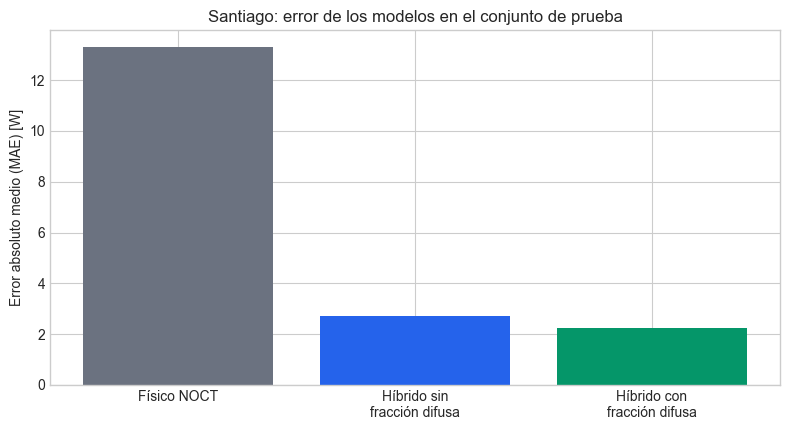

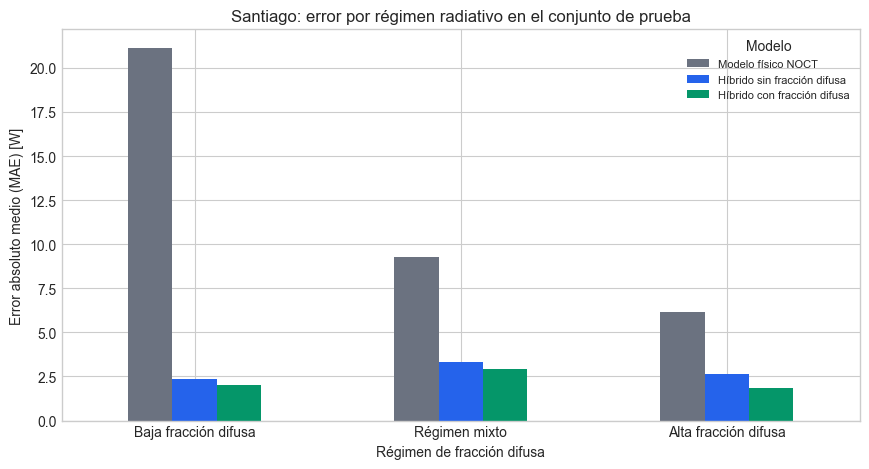

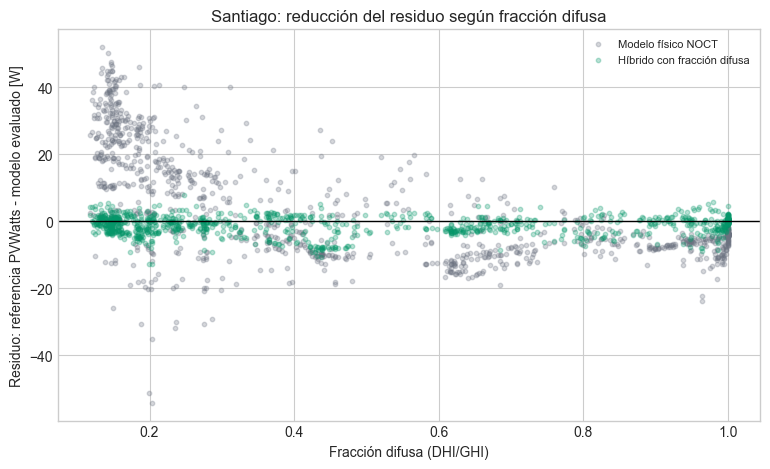

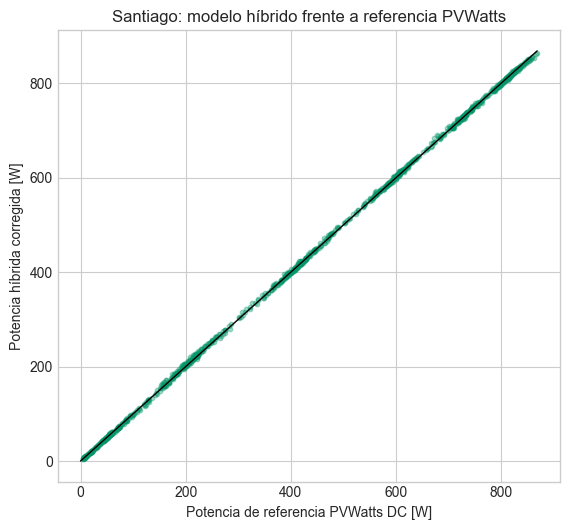

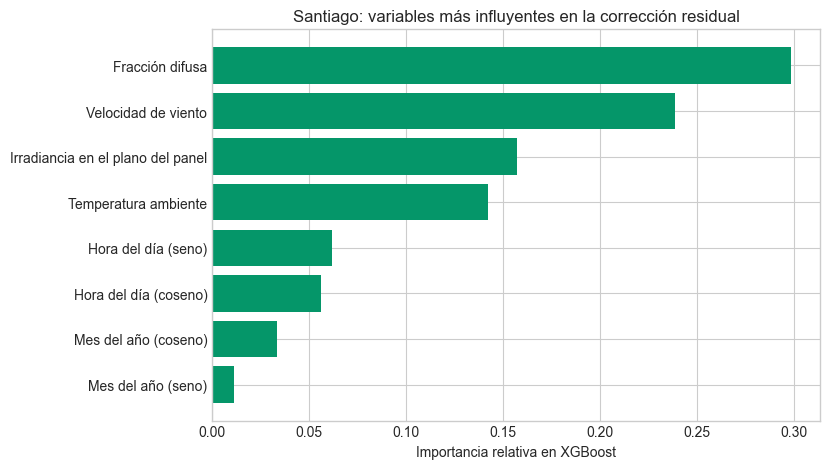

In [10]:
def savefig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.show()

# Error global en test.
plt.figure(figsize=(8.0, 4.4))
plot_df = metrics_test.copy()
plot_df["modelo"] = pd.Categorical(plot_df["modelo"], categories=MODEL_ORDER, ordered=True)
plot_df = plot_df.sort_values("modelo")
plt.bar(plot_df["modelo"].map(MODEL_GRAPH_LABELS), plot_df["MAE_W"], color=["#6b7280", "#2563eb", "#059669"])
plt.ylabel("Error absoluto medio (MAE) [W]")
plt.title("Santiago: error de los modelos en el conjunto de prueba")
plt.xticks(rotation=0, ha="center")
savefig(OUT_DIR / "bar_mae_modelos_test_santiago.png")

# Error por regimen en test.
plt.figure(figsize=(8.8, 4.8))
pivot = metrics_regimen.pivot(index="regimen_fd", columns="modelo", values="MAE_W")
pivot = pivot.reindex(REGIMEN_ORDER)
pivot = pivot[MODEL_ORDER]
pivot = pivot.rename(index=REGIMEN_LABELS, columns=MODEL_LEGEND_LABELS)
pivot.plot(kind="bar", ax=plt.gca(), color=["#6b7280", "#2563eb", "#059669"])
plt.ylabel("Error absoluto medio (MAE) [W]")
plt.xlabel("Régimen de fracción difusa")
plt.title("Santiago: error por régimen radiativo en el conjunto de prueba")
plt.xticks(rotation=0)
plt.legend(title="Modelo", fontsize=8)
savefig(OUT_DIR / "bar_mae_por_regimen_modelos_santiago.png")

# Residuo vs fraccion difusa antes y despues de la correccion.
plt.figure(figsize=(7.8, 4.8))
res_noct = test_pred["p_ref_dc"] - test_pred["p_noct"]
res_hybrid = test_pred["p_ref_dc"] - test_pred["p_hybrid_con_fd"]
plt.scatter(test_pred["fd"], res_noct, s=10, alpha=0.28, label="Modelo físico NOCT", color="#6b7280")
plt.scatter(test_pred["fd"], res_hybrid, s=10, alpha=0.28, label="Híbrido con fracción difusa", color="#059669")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Fracción difusa (DHI/GHI)")
plt.ylabel("Residuo: referencia PVWatts - modelo evaluado [W]")
plt.title("Santiago: reducción del residuo según fracción difusa")
plt.legend(fontsize=8)
savefig(OUT_DIR / "scatter_residuo_vs_fd_noct_hibrido_santiago.png")

# Potencia hibrida corregida vs referencia.
plt.figure(figsize=(5.8, 5.4))
plt.scatter(test_pred["p_ref_dc"], test_pred["p_hybrid_con_fd"], s=10, alpha=0.35, color="#059669")
max_val = max(test_pred["p_ref_dc"].max(), test_pred["p_hybrid_con_fd"].max())
plt.plot([0, max_val], [0, max_val], color="black", linewidth=1)
plt.xlabel("Potencia de referencia PVWatts DC [W]")
plt.ylabel("Potencia híbrida corregida [W]")
plt.title("Santiago: modelo híbrido frente a referencia PVWatts")
savefig(OUT_DIR / "scatter_phybrid_con_fd_vs_pref_santiago.png")

# Importancia de variables del modelo con fraccion difusa.
plt.figure(figsize=(8.4, 4.8))
imp = importance_con_fd.sort_values("importance", ascending=True).copy()
imp["feature_label"] = imp["feature"].map(FEATURE_LABELS).fillna(imp["feature"])
plt.barh(imp["feature_label"], imp["importance"], color="#059669")
plt.xlabel("Importancia relativa en XGBoost")
plt.title("Santiago: variables más influyentes en la corrección residual")
savefig(OUT_DIR / "bar_importancia_xgboost_con_fd_santiago.png")

## 9. Guardado de resultados

In [11]:
metrics_all.to_csv(OUT_DIR / "metricas_modelos_train_test_santiago.csv", index=False)
metrics_test.to_csv(OUT_DIR / "metricas_modelos_test_santiago.csv", index=False)
metrics_regimen.to_csv(OUT_DIR / "metricas_modelos_test_por_regimen_santiago.csv", index=False)
cv_metrics.to_csv(OUT_DIR / "validacion_temporal_timeseries_split_santiago.csv", index=False)
importance_con_fd.to_csv(OUT_DIR / "importancia_xgboost_con_fd_santiago.csv", index=False)
importance_sin_fd.to_csv(OUT_DIR / "importancia_xgboost_sin_fd_santiago.csv", index=False)

test_pred.to_csv(OUT_DIR / "predicciones_test_modelo_hibrido_santiago.csv", index=False)
train_pred.to_csv(OUT_DIR / "predicciones_train_modelo_hibrido_santiago.csv", index=False)

metadata = {
    "input_file": str(INPUT_FILE),
    "output_dir": str(OUT_DIR),
    "target": TARGET,
    "features_base": FEATURES_BASE,
    "features_with_fd": FEATURES_WITH_FD,
    "test_fraction": TEST_FRACTION,
    "split_type": "chronological_holdout_last_fraction",
    "p_ref_min_relative_error": P_REF_MIN_RELATIVE_ERROR,
    "xgboost_params": XGB_PARAMS,
    "notes": [
        "El modelo aprende el residuo epsilon = P_ref - P_NOCT.",
        "El modelo sin fd evita DHI, DNI y GHI para no reconstruir implicitamente la fraccion difusa.",
        "La evaluacion principal usa separacion temporal, no aleatoria.",
        "Las importancias de variables son diagnosticas y no constituyen evidencia causal.",
    ],
}

with open(OUT_DIR / "metadata_modelo_hibrido_santiago.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=4, ensure_ascii=False)

print("Resultados guardados en:", OUT_DIR)
print("\nMetricas test:")
print(metrics_test.to_string(index=False))

Resultados guardados en: outputs\04_modelo_hibrido_xgboost_santiago

Metricas test:
dataset                             modelo    n  n_error_relativo     MAE_W    RMSE_W  Bias_W_modelo_menos_ref       R2  Error_relativo_promedio  Mejora_MAE_vs_NOCT_pct
   test                 Modelo físico NOCT 1054               947 13.296102 17.103093                -4.049339 0.996300                 0.039592                0.000000
   test Modelo híbrido sin fracción difusa 1054               947  2.702791  3.727646                 0.924285 0.999824                 0.009406               79.672303
   test Modelo híbrido con fracción difusa 1054               947  2.224713  3.013470                 1.127999 0.999885                 0.008264               83.267929


## 10. Lectura preliminar

La conclusion metodologica debe basarse en la comparacion del conjunto de prueba:

- Si el híbrido con fracción difusa mejora al NOCT base, entonces existe estructura residual aprovechable.
- Si el híbrido con fracción difusa mejora al híbrido sin fracción difusa, entonces la fracción difusa aporta información marginal bajo esta configuracion.
- Si la mejora aparece solo en entrenamiento y no en prueba, no debe interpretarse como mejora real.

Esta etapa sigue usando una referencia simulada de PVWatts, por lo que los resultados no sustituyen una validacion experimental con mediciones reales.